In [1]:
# Import Libraries
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2025-10-06 15:33:36.798518: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759743216.825738  456685 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759743216.833969  456685 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759743216.857010  456685 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759743216.857053  456685 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759743216.857056  456685 computation_placer.cc:177] computation placer alr

In [2]:
# Configuration
IMG_SIZE = 128
DATA_PATH = "../Data/Scores"
BATCH_SIZE = 32
EPOCHS = 20

In [5]:
# Load Dataset
X, y, class_names = [], [], []
class_map = {}

print("[INFO] Loading dataset...")

for shape_name in os.listdir(DATA_PATH): 
    shape_path = os.path.join(DATA_PATH, shape_name)
    if not os.path.isdir(shape_path):
        continue
    
    for score in os.listdir(shape_path): 
        score_path = os.path.join(shape_path, score)
        if not os.path.isdir(score_path):
            continue
        
        label = f"{shape_name}_{score}"
        if label not in class_map:
            class_map[label] = len(class_map)
            class_names.append(label)
        
        for file in os.listdir(score_path):
            if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".jfif", ".webp")):
                path = os.path.join(score_path, file)
                img = cv2.imread(path)
                if img is None:
                    continue
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(class_map[label])

X = np.array(X, dtype="float32") / 255.0
y = np.array(y)
y_cat = to_categorical(y, num_classes=len(class_map))

print(f"[INFO] Dataset loaded: {X.shape[0]} samples, {len(class_map)} classes")

[INFO] Loading dataset...
[INFO] Dataset loaded: 4298 samples, 34 classes


In [7]:
# Preprocess Labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded, num_classes=len(class_names))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)

print(f"[INFO] Train: {X_train.shape}, Test: {X_test.shape}")

[INFO] Train: (3438, 128, 128, 3), Test: (860, 128, 128, 3)


In [8]:
# Build MobileNet Model
print("[INFO] Building MobileNetV2...")

base_model = MobileNetV2(
    include_top=False,
    weights=None,  # training from scratch since no pretrained weights needed
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

[INFO] Building MobileNetV2...


2025-10-06 15:50:39.685440: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 34)             │        43,554 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,301,538 (8.78 MB)

 Trainable params: 2,267,426 (8.65 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [9]:
# Train Model
print("[INFO] Training MobileNetV2...")

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    verbose=1
)

[INFO] Training MobileNetV2...
Epoch 1/20


/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-10-06 15:51:46.680527: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 50331648 exceeds 10% of free system memory.
2025-10-06 15:51:46.704584: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 50331648 exceeds 10% of free system memory.
2025-10-06 15:51:46.742225: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 50331648 exceeds 10% of free system memory.
2025-10-06 15:51:46.773819: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 51916800 exceeds 10% of free system memory.
2025-1

108/108 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.2248 - loss: 2.6853 - val_accuracy: 0.1198 - val_loss: 3.3899
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 104s 961ms/step - accuracy: 0.6575 - loss: 1.1609 - val_accuracy: 0.1198 - val_loss: 3.3015
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 105s 974ms/step - accuracy: 0.7019 - loss: 0.9696 - val_accuracy: 0.1198 - val_loss: 3.3103
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.7191 - loss: 0.8423 - val_accuracy: 0.1198 - val_loss: 3.3557
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.7129 - loss: 0.8467 - val_accuracy: 0.0267 - val_loss: 3.3965
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.7171 - loss: 0.8161 - val_accuracy: 0.1198 - val_loss: 3.4857
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 107s 986ms/step - accuracy: 0.7566 - loss: 0.7326 - val_accuracy: 0.1198 - val_loss: 3.4802
Epoch 8/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.7323 - loss: 0.7342 - val_accura

In [10]:
# Evaluate Model
print("[INFO] Evaluating model...")

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true, y_pred_classes)
print(f"[RESULT] MobileNetV2 Accuracy: {acc:.4f}")

[INFO] Evaluating model...
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step 
[RESULT] MobileNetV2 Accuracy: 0.0093


In [11]:
# Safe classification report
all_labels = np.unique(np.concatenate((y_true, y_pred_classes)))

print(classification_report(
    y_true,
    y_pred_classes,
    labels=all_labels,
    target_names=[class_names[i] for i in all_labels]
))


                      precision    recall  f1-score   support

          Triangle_4       0.00      0.00      0.00         8
          Triangle_5       0.00      0.00      0.00       119
              Star_3       0.00      0.00      0.00        19
              Star_2       0.00      0.00      0.00         2
              Star_0       0.00      0.00      0.00         3
              Star_4       0.00      0.00      0.00        50
              Star_5       0.00      0.00      0.00        24
              Wave_3       0.00      0.00      0.00        23
              Wave_2       0.00      0.00      0.00         2
              Wave_4       0.00      0.00      0.00       103
            Circle_3       0.00      0.00      0.00        15
            Circle_0       0.00      0.00      0.00         1
            Circle_4       0.00      0.00      0.00        91
            Square_4       0.00      0.00      0.00        11
            Square_5       0.00      0.00      0.00       120
Overlap

/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

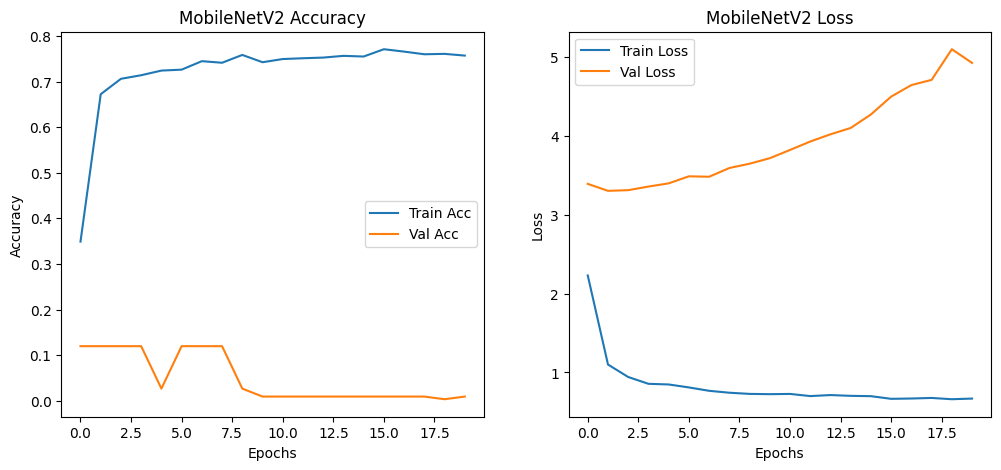

In [12]:
# Plot Accuracy & Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MobileNetV2 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()